**Goal**: Use Bayesian inference to estimate the value of \( g \) (gravitational acceleration) from noisy pendulum period measurements.

### The Physics Model
For a simple pendulum with small angles:
$$
T = 2\pi \sqrt{\frac{L}{g}} \quad \Rightarrow \quad g = \frac{4\pi^2 L}{T^2}
$$
We measure the period \( T \) multiple times. Each measurement has Gaussian noise due to timing errors.

### Bayesian Framework
Bayes' theorem:
$$
P(g \mid \mathbf{T}) = \frac{P(\mathbf{T} \mid g) \, P(g)}{P(\mathbf{T})}
$$

- Likelihood : Product of Gaussians (measurement errors) 
$$ 
 P(\mathbf{T} \mid g) 
$$
- Prior P(g) : Uniform (flat) prior over a reasonable range  
- Posterior  : Updated belief about g 
$$
P( g \mid \mathbf{T} )
$$

We will use a **grid approximation** (simple and visual) followed by a Metropolis-Hastings MCMC implementation.

#### How to Calculate the Likelihood 

The **likelihood** represents how probable the observed data \(\mathbf{T} = \{T_1, T_2, \dots, T_N\}\) is, given a particular value of \( g \).

**Assumptions**:
- Each measured period \( T_i \) is independent.
- The only uncertainty is Gaussian noise with known standard deviation \( \sigma_T \) (timing error).

For a single measurement \( T_i \), the probability density is given by the Gaussian (normal) distribution:
$$
P(T_i \mid g) = \frac{1}{\sqrt{2\pi}\sigma_T} \exp\left( -\frac{(T_i - T_{\text{model}}(g))^2}{2\sigma_T^2} \right)
$$
where the model prediction is:
$$
T_{\text{model}}(g) = 2\pi \sqrt{\frac{L}{g}}
$$

Since the measurements are independent, the **total likelihood** is the product of the individual probabilities:
$$
P(\mathbf{T} \mid g) = \prod_{i=1}^{N} P(T_i \mid g)
$$

In practice, we work with the **log-likelihood** to avoid numerical underflow and for easier computation:
$$
\log \mathcal{L}(g) = \log P(\mathbf{T} \mid g) = -\frac{N}{2}\log(2\pi\sigma_T^2) - \frac{1}{2\sigma_T^2} \sum_{i=1}^{N} \left( T_i - 2\pi \sqrt{\frac{L}{g}} \right)^2
$$

The constant term \(-\frac{N}{2}\log(2\pi\sigma_T^2)\) does not depend on \( g \), so when comparing different values of \( g \), we can ignore it. The likelihood is then proportional to:
$$
\mathcal{L}(g) \propto \exp\left( -\frac{1}{2\sigma_T^2} \sum_{i=1}^{N} \left( T_i - T_{\text{model}}(g) \right)^2 \right)
$$

This is exactly what we compute in the grid approximation and MCMC sections.

- **Likelihood** \( P(\mathbf{T} \mid g) \): Product of Gaussians (measurement errors)  
- **Prior** \( P(g) \): Uniform (flat) prior over a reasonable range  
- **Posterior** \( P(g \mid \mathbf{T}) \): Updated belief about \( g \)

We will use a **grid approximation** (simple and visual) followed by a Metropolis-Hastings MCMC implementation.



#### How to Calculate the Likelihood 

The **likelihood** represents how probable the observed data \(\mathbf{T} = \{T_1, T_2, \dots, T_N\}\) is, given a particular value of \( g \).

**Assumptions**:
- Each measured period \( T_i \) is independent.
- The only uncertainty is Gaussian noise with known standard deviation \( \sigma_T \) (timing error).

For a single measurement \( T_i \), the probability density is given by the Gaussian (normal) distribution:
$$
P(T_i \mid g) = \frac{1}{\sqrt{2\pi}\sigma_T} \exp\left( -\frac{(T_i - T_{\text{model}}(g))^2}{2\sigma_T^2} \right)
$$
where the model prediction is:
$$
T_{\text{model}}(g) = 2\pi \sqrt{\frac{L}{g}}
$$

Since the measurements are independent, the **total likelihood** is the product of the individual probabilities:
$$
P(\mathbf{T} \mid g) = \prod_{i=1}^{N} P(T_i \mid g)
$$

In practice, we work with the **log-likelihood** to avoid numerical underflow and for easier computation:
$$
\log \mathcal{L}(g) = \log P(\mathbf{T} \mid g) = -\frac{N}{2}\log(2\pi\sigma_T^2) - \frac{1}{2\sigma_T^2} \sum_{i=1}^{N} \left( T_i - 2\pi \sqrt{\frac{L}{g}} \right)^2
$$

The constant term \(-\frac{N}{2}\log(2\pi\sigma_T^2)\) does not depend on \( g \), so when comparing different values of \( g \), we can ignore it. The likelihood is then proportional to:
$$
\mathcal{L}(g) \propto \exp\left( -\frac{1}{2\sigma_T^2} \sum_{i=1}^{N} \left( T_i - T_{\text{model}}(g) \right)^2 \right)
$$

This is exactly what we compute in the grid approximation and MCMC sections.

- **Likelihood** \( P(\mathbf{T} \mid g) \): Product of Gaussians (measurement errors)  
- **Prior** \( P(g) \): Uniform (flat) prior over a reasonable range  
- **Posterior** \( P(g \mid \mathbf{T}) \): Updated belief about \( g \)

We will use a **grid approximation** (simple and visual) followed by a Metropolis-Hastings MCMC implementation.



True g: 9.81
True period: 2.0061
Measured periods: 1.9975 +/- 0.0468


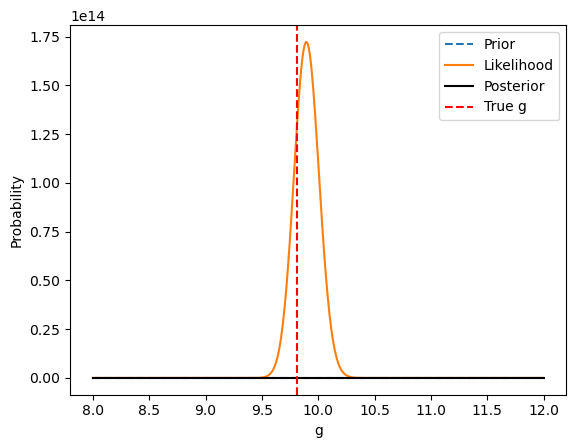

Best estimate of g: 9.892


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

g_true = 9.81
L = 1.0

true_T = 2 * np.pi * np.sqrt(L / g_true)

np.random.seed(42)
T_data = true_T + np.random.normal(0, 0.05, 20)

print("True g:", g_true)
print("True period:", round(true_T, 4))
print("Measured periods:", round(T_data.mean(), 4), "+/-", round(T_data.std(), 4))


g_grid = np.linspace(8, 12, 500)
prior = np.ones_like(g_grid)  # flat prior

def log_likelihood(g):
    T_model = 2 * np.pi * np.sqrt(L / g)
    return np.sum(norm.logpdf(T_data, loc=T_model, scale=0.05))

likelihood = np.exp([log_likelihood(g) for g in g_grid])
posterior = likelihood * prior

posterior /= np.trapz(posterior, g_grid)


plt.plot(g_grid, prior, '--', label='Prior')
plt.plot(g_grid, likelihood, label='Likelihood')
plt.plot(g_grid, posterior, 'k', label='Posterior')
plt.axvline(g_true, color='red', linestyle='--', label='True g')

plt.xlabel('g')
plt.ylabel('Probability')
plt.legend()
plt.show()


g_best = g_grid[np.argmax(posterior)]
print("Best estimate of g:", round(g_best, 3))